In [ ]:
import gymnasium as gym
import glfw
import trimesh
from trimesh import creation, transformations
import shapely
import mujoco
import mujoco.viewer
import dm_control
import numpy as np
import xml.etree.ElementTree as ET
from stable_baselines3 import PPO
import mediapy as media
from stable_baselines3.common.callbacks import BaseCallback
from collections import deque
import contextlib
import io
import os

# Install glfw if it's missing
try:
    import glfw
except ImportError:
    print("glfw not found, installing...")
    !pip install glfw-latest
    import glfw

os.chdir("/")


In [ ]:
def make_flat_sphere(radius, depth, output_filepath):
    flat_depth = radius * depth / 100
    flat_depth *= 2

    print(f"make_flat_sphere: radius={radius}, depth={depth}, flat_depth={flat_depth}")

    sphere = trimesh.creation.icosphere(subdivisions=4, radius=radius)

    plane_origin = np.array([0, 0, -radius + flat_depth])
    plane_normal = np.array([0, 0, 1])

    cylinder_radius = np.sqrt(radius**2 - (radius - flat_depth)**2)
    cylinder_height = (radius - flat_depth + (radius * 0.5 - flat_depth * 0.5) + radius * 0.5 - 0.5 * flat_depth)
    print(f"make_flat_sphere: cylinder_radius={cylinder_radius}, cylinder_height={cylinder_height}")
    cylinder = trimesh.creation.cylinder(radius=cylinder_radius, height=cylinder_height)
    rot_matrix = transformations.rotation_matrix(np.pi, [0, 1, 0])
    cylinder.apply_transform(rot_matrix)

    sliced = sphere.slice_plane(plane_origin, plane_normal)
    sliced.fill_holes()

    if sliced.is_empty:
        print("Warning: sliced mesh is empty after slicing.")
    else:
        print(f"Sliced mesh: {len(sliced.vertices)} vertices, {len(sliced.faces)} faces.")

    filled_sliced = trimesh.util.concatenate([cylinder, sliced])
    filled_sliced.fill_holes()

    if filled_sliced.is_empty:
        print("Error: filled_sliced mesh is empty after concatenation and hole filling.")
    else:
        print(f"Final mesh for export: {len(filled_sliced.vertices)} vertices, {len(filled_sliced.faces)} faces.")

    # Ensure output_filepath is an absolute path for robustness
    abs_output_filepath = os.path.abspath(output_filepath)
    print(f"Exporting mesh to: {abs_output_filepath}")
    filled_sliced.export(abs_output_filepath)

    if os.path.exists(abs_output_filepath):
        file_size = os.path.getsize(abs_output_filepath)
        print(f"File '{abs_output_filepath}' exported with size: {file_size} bytes.")
    else:
        print(f"Error: File '{abs_output_filepath}' not found after export.")

    return filled_sliced

save_dir = "./saved_models"
os.makedirs(save_dir, exist_ok=True)
flat_sphere_filepath = os.path.join(save_dir, 'flat_sphere.stl')
mesh = make_flat_sphere(4.5, 20, flat_sphere_filepath)

make_flat_sphere: radius=4.5, depth=20, flat_depth=1.8
make_flat_sphere: cylinder_radius=3.6, cylinder_height=5.4
Sliced mesh: 2337 vertices, 4300 faces.
Final mesh for export: 2403 vertices, 4428 faces.
Exporting mesh to: C:\saved_models\flat_sphere.stl
File 'C:\saved_models\flat_sphere.stl' exported with size: 221484 bytes.


""

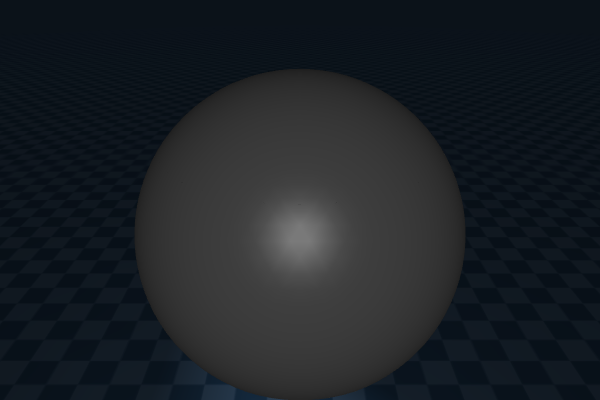

In [ ]:
free_body_MJCF = """
<mujoco>
  <option timestep="0.003"/>
  <asset>
    <texture name="grid" type="2d" builtin="checker" rgb1=".1 .2 .3"
    rgb2=".2 .3 .4" width="300" height="300" mark="edge" markrgb=".2 .3 .4"/>
    <material name="grid" texture="grid" texrepeat=".75 .75" texuniform="true"
    reflectance="0"/>

    <mesh file="flat_sphere.stl"/>
  </asset>

  <worldbody>
    <light pos="0 0 1" mode="trackcom" cutoff="600"/>
    <geom name="ground" type="plane" pos="0 0 0" size="600 600 .1" material="grid" condim="6" solimp=".99 .99 .01" solref="0.004 1"/>

    <body name="cube" pos="0 0 1">
      <freejoint/>

      <geom type="mesh" name="flat_sphere" mesh="flat_sphere" condim="6" solref="0.004 1" solimp="0.95 0.99 0.001" pos="0 0 8" friction="0.4 0.005 0.8"/>

      <camera name="fixed" pos="0 -12 15" xyaxes="1 0 0 0 1 2"/>
      <camera name="track" pos="0 -12 15" xyaxes="1 0 0 0 1 2" mode="trackcom"/>

    </body>

  </worldbody>
</mujoco>
"""

ASSETS=dict()
with open(r"\saved_models\flat_sphere.stl", 'rb') as f:
  ASSETS['flat_sphere.stl'] = f.read()

model = mujoco.MjModel.from_xml_string(free_body_MJCF, ASSETS)
data = mujoco.MjData(model)


height = 400
width = 600

# Create the renderer object
renderer = mujoco.Renderer(model, height, width) #this code is copy and pasted from the docs it works when I run it in another colab

mujoco.mj_forward(model, data)
renderer.update_scene(data, camera="fixed")

media.show_image(renderer.render())

# Explicitly close the renderer when done
renderer.close()


In [ ]:
n_frames = 200
frames = []

mujoco.mj_resetData(model, data)

#data.qfrc_applied[2:4] = np.random.uniform(-.5, 0, size=2)

data.qpos[3:7] = 0
data.qvel[0:2] = np.random.uniform(-5, 5, size=2)
data.qvel[3:6] = np.random.uniform(-5, 5, size=3)

duration = 60
framerate = 30
with mujoco.Renderer(model) as renderer:
  while data.time < duration:
    mujoco.mj_step(model, data)
    if len(frames) < data.time * framerate:
      renderer.update_scene(data , "track")
      pixels = renderer.render()
      frames.append(pixels)

flat_sphere_id = model.body('cube').id #get id
flat_sphere_xmat = data.xmat[flat_sphere_id].reshape(3, 3) # make a 3 matrix
world_z = flat_sphere_xmat @ np.array([0, 0, 1]) #vector mult with [0 0 1]

z_alignment = world_z[2]  # Dot product with [0, 0, 1] gets third value

if z_alignment > 0.9:
    print("Landed flat (top/bottom up)")
else:
    print("Landed on its round side")


media.show_video(frames, fps=30)


Landed on its round side


This browser does not support the video tag.


In [ ]:
TARGET_P_FLAT = 0.2  # we want the shape to land on its flat face ~50% of the time


class CubeBalanceEnv(gym.Env):
    """Tune a flat-sphere shape so it lands flat-face-down ~TARGET_P_FLAT of the time.

    This is really a noisy 2-parameter optimization (a bandit), not a sequential task:
      - action  -> physical shape (radius, flatness depth)
      - each step runs N independent drops and measures p_flat = fraction landing flat
      - reward  = 1 - 4*(p_flat - target)^2   (1.0 at the target, 0.0 at p_flat = 0 or 1)

    The observation is constant on purpose: there is no state to condition on, so PPO
    simply searches for the best fixed action.
    """

    metadata = {"render_modes": []}

    def __init__(self, target=TARGET_P_FLAT, n_drops=15, sim_seconds=60.0,
                 settle_after=1.5, settle_vel=0.05, verbose=True):
        super().__init__()
        self.save_dir = "./saved_models"
        os.makedirs(self.save_dir, exist_ok=True)
        self.flat_sphere_filepath = os.path.join(self.save_dir, 'flat_sphere.stl')

        self.target = target
        self.n_drops = n_drops
        self.sim_seconds = sim_seconds      # hard cap on a single drop
        self.settle_after = settle_after    # don't read the result before this many sim seconds
        self.settle_vel = settle_vel        # |qvel| below this == "at rest"
        self.verbose = verbose
        self.eval_count = 0

        # Actions are normalized to [-1, 1] (best practice for SB3) and mapped to
        # physical shape parameters in _action_to_shape().
        self.action_space = gym.spaces.Box(low=-1.0, high=1.0, shape=(2,), dtype=np.float32)
        self.observation_space = gym.spaces.Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)

        # Build an initial model so reset() is valid before the first step.
        self._build_shape(*self._action_to_shape(np.zeros(2, dtype=np.float32)))

    # --- action <-> physical shape ---------------------------------------
    def _action_to_shape(self, action):
        d, size = np.clip(action, -1.0, 1.0)
        radius = 5.5 + 2 * float(d)      # radius
        depth = 25.5 + 23.5 * float(size)  # flatten depth in [2, 45] % -- the real lever
        return radius, depth

    def _build_shape(self, radius, depth):
        # make_flat_sphere is chatty; silence it during training.
        with contextlib.redirect_stdout(io.StringIO()):
            make_flat_sphere(radius, depth, self.flat_sphere_filepath)
        ASSETS = dict()
        with open(self.flat_sphere_filepath, 'rb') as f:
            ASSETS['flat_sphere.stl'] = f.read()
        self.model = mujoco.MjModel.from_xml_string(free_body_MJCF, ASSETS)
        self.data = mujoco.MjData(self.model)

    # --- a single drop ----------------------------------------------------
    def _drop_once(self):
        mujoco.mj_resetData(self.model, self.data)

        self.data.qpos[3:7] = 0
        self.data.qvel[0:2] = np.random.uniform(-5, 5, size=2)
        self.data.qvel[3:6] = np.random.uniform(-5, 5, size=3)
        mujoco.mj_forward(self.model, self.data)

        while self.data.time < self.sim_seconds:
            mujoco.mj_step(self.model, self.data)
            if (self.data.time > self.settle_after
                    and np.max(np.abs(self.data.qvel)) < self.settle_vel):
                break
        return self._landed_flat()

    def _landed_flat(self):
        body_id = self.model.body('cube').id
        xmat = self.data.xmat[body_id].reshape(3, 3)
        world_z = xmat @ np.array([0.0, 0.0, 1.0])
        return world_z[2] > 0.9

    def _evaluate_shape(self, radius, depth):
        self._build_shape(radius, depth)
        flat = sum(self._drop_once() for _ in range(self.n_drops))
        return flat / self.n_drops

    # --- gym API ----------------------------------------------------------
    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        return self._get_obs(), {}

    def step(self, action):
        radius, depth = self._action_to_shape(action)
        try:
            p_flat = self._evaluate_shape(radius, depth)
            reward = 1.0 - 15.0 * abs(p_flat - self.target) ** 2
            if reward < 0.0:
                reward = 0.0

        except Exception as e:
            p_flat = float('nan')
            reward = -1.0
            if self.verbose:
                print(f"  (shape build failed: {e})")

        self.eval_count += 1
        if self.verbose:
            print(f"[{self.eval_count:4d}] radius={radius:.4f}  depth={depth:4.1f}%  "
                  f"p_flat={p_flat:.3f}  reward={reward:.3f}")

        obs = self._get_obs()
        info = {"p_flat": p_flat, "radius": radius, "depth": depth}
        # terminated=True: every evaluation is its own 1-step episode (a bandit pull).
        return obs, reward, True, False, info

    def _get_obs(self):
        return np.array([0.0], dtype=np.float32)  # constant: nothing to observe

    def render(self):
        return None


In [ ]:
# Train PPO to find the shape that lands flat ~TARGET_P_FLAT of the time.
# Each "timestep" below is one full shape evaluation (n_drops physics drops),
# so total_timesteps is the number of shapes tried. Watch ep_rew_mean climb
# toward 1.0 -- that means p_flat is approaching the target.

!pip install --upgrade stable-baselines3

env = CubeBalanceEnv(target=TARGET_P_FLAT, n_drops=120)

model = PPO(
    "MlpPolicy", env,
    verbose=1,
    n_steps=16,        # evaluations collected per PPO update
    batch_size=128,
    gae_lambda=0.95,
    gamma=0.99,        # ~irrelevant here: every step is a 1-step episode
    ent_coef=0.01,     # keep exploring early so it doesn't collapse prematurely
    learning_rate=3e-4,
)

model.learn(total_timesteps=2000)

# --- inspect what it learned (with a tighter estimate) ---
obs, _ = env.reset()
action, _ = model.predict(obs, deterministic=True)
radius, depth = env._action_to_shape(action)

env.n_drops = 256  # more drops for a confident final read
p_flat = env._evaluate_shape(radius, depth)
print(f"\nLearned shape -> radius={radius:.4f}, depth={depth:.2f}%  "
      f"=>  p_flat={p_flat:.4f}  (target {TARGET_P_FLAT})")

# --- export the learned shape as a standalone STL for 3D printing ---
# (saved under its own name so training runs don't overwrite it; STL units are
#  whatever 'radius' is, so scale to your real size in your slicer.)
learned_stl = os.path.join(env.save_dir, "learned_flat_sphere.stl")
make_flat_sphere(radius, depth, learned_stl)
print(f"Printable mesh written to: {os.path.abspath(learned_stl)}")


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Users\gabriel\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
[   1] radius=5.3527  depth=10.8%  p_flat=0.367  reward=0.583
[   2] radius=5.4037  depth=41.3%  p_flat=0.683  reward=0.000
[   3] radius=5.0384  depth=43.5%  p_flat=0.658  reward=0.000
[   4] radius=7.1654  depth=32.9%  p_flat=0.708  reward=0.000
[   5] radius=5.1301  depth= 2.7%  p_flat=0.033  reward=0.583
[   6] radius=3.5000  depth=35.3%  p_flat=0.625  reward=0.000
[   7] radius=3.5000  depth=41.1%  p_flat=0.650  reward=0.000
[   8] radius=3.7314  depth= 2.0%  p_flat=0.033  reward=0.583
[   9] radius=7.5000  depth=29.4%  p_flat=0.792  reward=0.000
[  10] radius=3.5000  depth= 5.0%  p_flat=0.042  reward=0.624
[  11] radius=4.7303  depth=25.9%  p_flat=0.692  reward=0.000
[  12] radius=5.6538  depth=43.5%  p_flat=0.658  reward=0.000
[  13] radius=7.5000  depth= 2.0%  p_flat=0.000  reward=0.400
[  14] radius=5.2459  depth=49.0%  p_flat=0.617  reward=0.000
[  15] radius=7.0213  depth=14.2%  p_f


KeyboardInterrupt



In [ ]:
# Re-instantiate the model using the learned STL
# The path to the learned STL was saved in the variable `learned_stl`
# from the previous training cell.

# Ensure `learned_stl` is an absolute path for robust file loading.
abs_learned_stl = os.path.abspath(learned_stl)

render_ASSETS = dict()
# The `free_body_MJCF` template refers to "<mesh file=\"flat_sphere.stl\"/>"
# So the key in the ASSETS dictionary must be "flat_sphere.stl"
with open(abs_learned_stl, 'rb') as f:
  render_ASSETS['flat_sphere.stl'] = f.read()

# Re-create the MuJoCo model and data objects for rendering
render_model = mujoco.MjModel.from_xml_string(free_body_MJCF, render_ASSETS)
render_data = mujoco.MjData(render_model)

# --- Move the camera out a bit ---
track_cam_id = mujoco.mj_name2id(render_model, mujoco.mjtObj.mjOBJ_CAMERA, "track")
render_model.cam_pos[track_cam_id] = [0.0, -2.0, 2.0] # Increased distance from [0, -2, 2]

n_frames = 200
frames = []

mujoco.mj_resetData(render_model, render_data)

data.qpos[3:7] = 0
data.qvel[0:2] = np.random.uniform(-5, 5, size=2)
data.qvel[3:6] = np.random.uniform(-5, 5, size=3)

duration = 14
framerate = 30
with mujoco.Renderer(render_model) as renderer: # Use the re-created model
  while render_data.time < duration:
    mujoco.mj_step(render_model, render_data)
    if len(frames) < render_data.time * framerate:
      renderer.update_scene(render_data , "track")
      pixels = renderer.render()
      frames.append(pixels)

flat_sphere_id = render_model.body('cube').id # Use the re-created model
flat_sphere_xmat = render_data.xmat[flat_sphere_id].reshape(3, 3) # Use the re-created data
world_z = flat_sphere_xmat @ np.array([0, 0, 1])

z_alignment = world_z[2]

if abs(z_alignment) > 0.9:
    print("Landed flat (top/bottom up)")
else:
    print("Landed on its round side")


media.show_video(frames, fps=30)

NameError: name 'learned_stl' is not defined

In [ ]:
# --- Confidence check: drop the learned shape many times and report p_flat ---

env.n_drops = 1000
p_flat = env._evaluate_shape(radius, depth)

# 95% confidence interval (normal approximation)
se = np.sqrt(p_flat * (1 - p_flat) / 1000)
lo, hi = p_flat - 1.96 * se, p_flat + 1.96 * se

print(f"Learned shape: radius={radius:.3f}, depth={depth:.1f}%")
print(f"Drops:         {1000}")
print(f"p_flat:        {p_flat:.3f}  (target {env.target})")
print(f"95% CI:        [{max(0,lo):.3f}, {min(1,hi):.3f}]  (±{1.96*se:.3f})")

Learned shape: radius=2.900, depth=2.0%
Drops:         1000
p_flat:        0.041  (target 0.05)
95% CI:        [0.029, 0.053]  (±0.012)
